# 14 — Building Setback Generation (建筑退线)

**Core question**: Every building must keep a minimum distance from the road
redline (道路红线) and from its own property lines. Given a parcel boundary and
a road network, what area is actually *buildable*? How do different setback
regimes change the site's capacity?

**Three approaches**:
1. Simple buffer offsets — per-edge inward offsets of the parcel (mitered corners)
2. Road-network-aware setbacks — buffer road centerlines by redline width + class setback
3. Footprint generator — place feasible building footprints inside the buildable envelope

CPU + numpy + shapely. No GPU.

**Standards referenced**: DB11/T 996-2013 (Beijing construction project planning
design rules), GB 50180-2018 (城市居住区规划设计标准), GB 50016-2014 (防火间距).
Exact numbers always come from the site's regulatory plan (控规); this notebook
uses typical reference values.


## 0. Background — What Is a Building Setback?

**建筑退线 (building setback / 建筑控制线, building control line)** is the minimum
horizontal distance between a building footprint and a constraint line:

1. **道路红线退让 (setback from road redline)** — the redline is the legal boundary
   of road land. Buildings must stand back so streets keep their statutory width
   and pedestrians/vehicles keep their sight lines.
2. **用地边界退让 (setback from property lines)** — buildings step back from the
   parcel boundary toward neighbours (privacy, light, fire access, load-bearing).
3. **其他线界 (other control lines)** — 河道蓝线 (blue line), 绿地绿线 (green line),
   power corridors, and 日照间距 (solar spacing, see notebook 10) impose further
   constraints that can dominate residential layouts.

### Why setbacks matter

- **Fire safety** — fire trucks need access lanes around buildings (GB 50016-2014
  requires 消防车道; fire separation between buildings: 多层-多层 ≥ 6 m, 高层-高层 ≥ 13 m).
- **Street quality** — a consistent setback creates a street wall and leaves room
  for sidewalks, trees, and underground utilities.
- **Light and ventilation** — the front setback contributes to daylighting of
  lower floors.
- **Regulation** — the 控规 (regulatory detailed plan) legally fixes control lines;
  the design cannot build past them.

### Typical reference values (Beijing practice)

| Constraint | Typical setback |
|---|---|
| 主干路 arterial redline | 10–15 m |
| 次干路 secondary redline | 5–10 m |
| 支路 local road redline | 3–5 m |
| Property line (residential) | 5 m |
| Property line (commercial/industrial) | 3 m |
| Fire separation 多层–多层 | 6 m |
| Fire separation 高层–高层 | 13 m |

The setback is *land use dependent*: commercial blocks may build right up to the
control line, while residential towers step far back. This notebook encodes the
setback as a geometric operation: the buildable envelope is the parcel shrunk by
the applicable setbacks. We compare three ways to compute that envelope.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MPLPolygon
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, box
from shapely.ops import unary_union
import shapely

from src.projection import transform_geometry, CRS_4326, CRS_4548
from src.generation import subdivide_boundary

# Plot style (house style of notebooks 10/11) + Chinese font support
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.sans-serif'] = ['Heiti SC', 'PingFang SC', 'STHeiti', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('numpy', np.__version__)
print('shapely', shapely.__version__)
print('geopandas', gpd.__version__)
print('Libraries loaded')


numpy 2.3.5
shapely 2.1.2
geopandas 1.1.4
Libraries loaded


In [2]:
# ---- Setback parameter tables (typical reference values) ----
# Road class -> (Chinese name, redline half-width, redline setback)
ROAD_CLASS_PARAMS = {
    'arterial':  {'name_zh': '主干路', 'half_width': 30.0, 'setback': 15.0},
    'secondary': {'name_zh': '次干路', 'half_width': 20.0, 'setback': 10.0},
    'local':     {'name_zh': '支路',   'half_width': 10.0, 'setback': 5.0},
}

# Land use -> property-line setback (typical)
PROPERTY_SETBACK_BY_USE = {
    'R': 5.0,   # residential
    'A': 5.0,   # public service
    'B': 3.0,   # commercial
    'M': 3.0,   # industrial
}

# Fire separation (GB 50016-2014) — minimum clear distance between buildings
FIRE_SEPARATION = {
    'low_low':   6.0,   # 多层-多层
    'high_low':  9.0,   # 高层-多层
    'high_high': 13.0,  # 高层-高层
}

print('=== Road class parameters (setback from redline) ===')
for cls, p in ROAD_CLASS_PARAMS.items():
    print(f'  {cls:10s} ({p["name_zh"]}): redline width {2*p["half_width"]:4.0f} m, '
          f'setback {p["setback"]:4.0f} m')
print()
print('=== Property-line setbacks ===')
for lu, d in PROPERTY_SETBACK_BY_USE.items():
    print(f'  land use {lu}: {d:.0f} m')
print()
print('=== Fire separation (GB 50016-2014) ===')
for k, v in FIRE_SEPARATION.items():
    print(f'  {k:11s}: {v:.0f} m')


=== Road class parameters (setback from redline) ===
  arterial   (主干路): redline width   60 m, setback   15 m
  secondary  (次干路): redline width   40 m, setback   10 m
  local      (支路): redline width   20 m, setback    5 m

=== Property-line setbacks ===
  land use R: 5 m
  land use A: 5 m
  land use B: 3 m
  land use M: 3 m

=== Fire separation (GB 50016-2014) ===
  low_low    : 6 m
  high_low   : 9 m
  high_high  : 13 m


## 1. Method 1: Simple Buffer Offsets

**Idea**: the buildable envelope is the parcel shrunk inward by each edge's
setback. Edges that face a road get the road-class setback; edges facing
neighbours get the property-line setback. Corners are *mitered*: the corner of
the envelope is the intersection of the two offset lines, so both constraints
hold at once.

```
            internal 5 m
        ┌─────────────────────────┐
        │   parcel                │
        │        ┌──────────┐     │
        │        │ buildable│     │  <- offset line (internal)
        │        │ envelope │     │
        └────────┴──────────┴─────┘
          internal 5 m        ↑
                     road-facing edge: 10 m (次干路)
```

**Algorithm** (per edge of a simple polygon):
1. For each edge, compute the inward unit normal and the offset line at the
   edge's setback distance.
2. The interior side of every offset line is a half-plane; the buildable
   envelope is the intersection of all half-planes, clipped to the parcel.
3. Validation: envelope ⊆ parcel, and distance from envelope to each edge
   equals the edge's setback.

**Limitation**: the constraint is assumed to be *the parcel edge itself*. This
is only true when the road redline coincides with the parcel edge — the next
section shows what happens when it does not.


In [3]:
def setback_envelope_by_edges(parcel, edge_setbacks, return_lines=False):
    """Buildable envelope via per-edge inward offsets (mitered corners).

    Parameters
    ----------
    parcel : shapely Polygon
        Parcel boundary (convex in the simple demo; works for typical parcels).
    edge_setbacks : list of float
        Setback per exterior-ring edge, aligned with the ring order.
    return_lines : bool
        Also return the offset LineStrings (for drawing).

    Returns
    -------
    Polygon (or tuple with offset lines).
    """
    coords = list(parcel.exterior.coords)[:-1]
    n = len(coords)
    assert len(edge_setbacks) == n, 'one setback per edge'
    interior = parcel.representative_point()
    ip = np.array([interior.x, interior.y])

    minx, miny, maxx, maxy = parcel.bounds
    diag = float(np.hypot(maxx - minx, maxy - miny))
    big_box = Polygon([(minx-diag, miny-diag), (maxx+diag, miny-diag),
                       (maxx+diag, maxy+diag), (minx-diag, maxy+diag)])

    envelope = big_box
    lines = []
    for i in range(n):
        a = np.array(coords[i])
        b = np.array(coords[(i + 1) % n])
        d = edge_setbacks[i]
        if d <= 1e-9:
            continue
        e = b - a
        norm = np.linalg.norm(e)
        t = e / norm                      # along-edge direction
        L = np.array([-e[1], e[0]]) / norm  # left normal
        s = np.sign(np.dot(ip - a, L))    # sign so L points to the interior
        L = s * L
        o = a + d * L                     # point on the inward offset line
        ext = diag
        # strip beyond the offset line (the 'outside' half of the line)
        strip = Polygon([o - t*ext, o + t*ext,
                         o + t*ext - L*ext, o - t*ext - L*ext])
        envelope = envelope.difference(strip)
        lines.append((LineString([o - t*ext, o + t*ext]), d))

    envelope = envelope.intersection(parcel)
    if return_lines:
        return envelope, lines
    return envelope


def edge_setbacks_by_side(parcel, rules):
    """Assign a setback to each ring edge by its compass side.

    `rules` maps 'E'/'N'/'W'/'S' to setbacks. Robust to ring winding and
    to which vertex the ring starts at (shapely's box() starts at the
    east edge, so positional lists are easy to get wrong).

    Returns (setbacks, side_names) aligned with the ring order.
    """
    ring = list(parcel.exterior.coords)[:-1]
    n = len(ring)
    minx, miny, maxx, maxy = parcel.bounds
    setbacks = []
    sides = []
    for i in range(n):
        a = np.array(ring[i])
        b = np.array(ring[(i + 1) % n])
        mx, my = (a + b) / 2
        if abs(mx - minx) < 1e-6:
            side = 'W'
        elif abs(mx - maxx) < 1e-6:
            side = 'E'
        elif abs(my - miny) < 1e-6:
            side = 'S'
        elif abs(my - maxy) < 1e-6:
            side = 'N'
        else:
            side = '?'
        setbacks.append(rules.get(side, 0.0))
        sides.append(side)
    return setbacks, sides


# ---- Demo parcel: 120 x 80 m, east edge faces a secondary road ----
parcel = box(0, 0, 120, 80)
edge_setbacks, side_names = edge_setbacks_by_side(
    parcel, {'E': 10.0, 'N': 5.0, 'W': 5.0, 'S': 5.0})
envelope, offset_lines = setback_envelope_by_edges(parcel, edge_setbacks, return_lines=True)

# Naive baseline: uniform 5 m buffer everywhere
uniform = parcel.buffer(-5.0)

print('=== Method 1: per-edge setback envelope ===')
print(f'Parcel area:            {parcel.area:7.1f} m²')
print(f'Buildable envelope:     {envelope.area:7.1f} m²  ({envelope.area/parcel.area*100:.1f}% of parcel)')
print(f'Naive uniform 5m:       {uniform.area:7.1f} m²  (under-cuts the road side)')
print(f'Envelope - naive:       {envelope.area - uniform.area:7.1f} m²')
print()

# Validation 1: envelope contained in parcel
print(f'Envelope within parcel: {parcel.covers(envelope)}')

# Validation 2: distance from envelope to each edge equals the edge setback
coords = list(parcel.exterior.coords)[:-1]
for i in range(4):
    edge = LineString([coords[i], coords[(i + 1) % 4]])
    dist = envelope.distance(edge)
    ok = abs(dist - edge_setbacks[i]) < 1e-6
    print(f'  {side_names[i]} edge: envelope distance = {dist:5.2f} m, setback = {edge_setbacks[i]:4.1f} m  {"OK" if ok else "MISMATCH"}')

# Validation 3: every point of the envelope satisfies all setbacks (spot check)
probe = envelope.representative_point()
pdist = [probe.distance(LineString([coords[i], coords[(i + 1) % 4]])) for i in range(4)]
print(f'Representative point distance to edges: {[f"{d:.2f}" for d in pdist]}')
print(f'Edge setbacks: {edge_setbacks}, sides: {side_names}')


=== Method 1: per-edge setback envelope ===
Parcel area:             9600.0 m²
Buildable envelope:      7350.0 m²  (76.6% of parcel)
Naive uniform 5m:        7700.0 m²  (under-cuts the road side)
Envelope - naive:        -350.0 m²

Envelope within parcel: True
  E edge: envelope distance = 10.00 m, setback = 10.0 m  OK
  N edge: envelope distance =  5.00 m, setback =  5.0 m  OK
  W edge: envelope distance =  5.00 m, setback =  5.0 m  OK
  S edge: envelope distance =  5.00 m, setback =  5.0 m  OK
Representative point distance to edges: ['62.50', '40.00', '57.50', '40.00']
Edge setbacks: [10.0, 5.0, 5.0, 5.0], sides: ['E', 'N', 'W', 'S']


findfont: Failed to find font weight bold, now using 400.


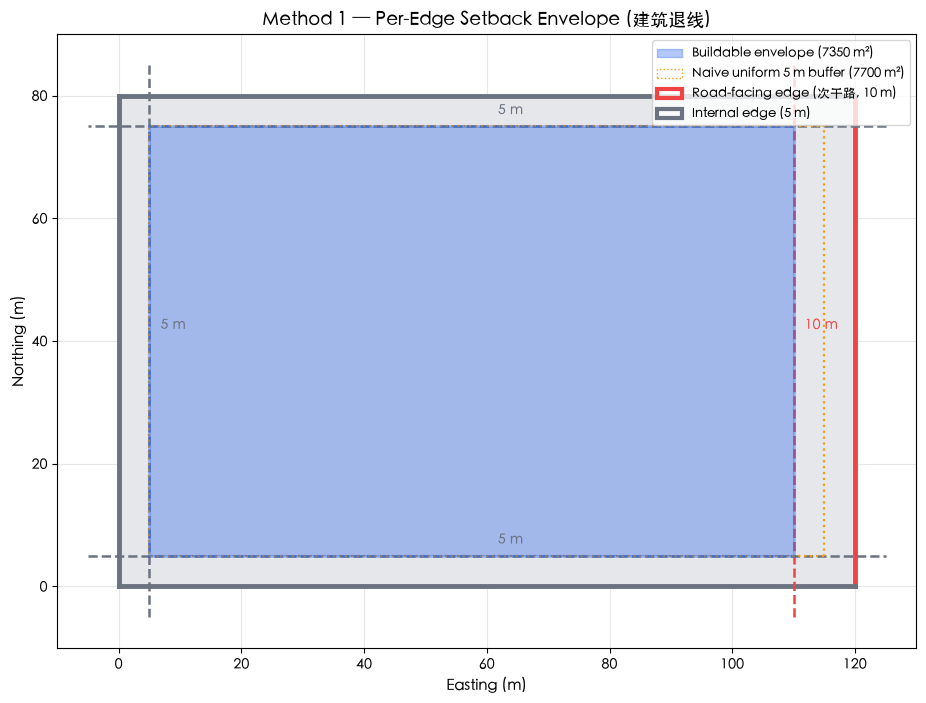

Saved ../outputs/14-method1-buffer-envelope.png


In [4]:
# ---- Figure 1: Method 1 — buffer offsets ----
fig, ax = plt.subplots(figsize=(9.5, 7))

coords = list(parcel.exterior.coords)
ax.add_patch(MPLPolygon(coords, facecolor='#e5e7eb', edgecolor='#374151', lw=1.4, zorder=2))

# edge classification: east edge road-facing (by side, ring-order agnostic)
EDGE_CLASS = ['road' if s == 'E' else 'internal' for s in side_names]
edge_colors = {'internal': '#6b7280', 'road': '#ef4444'}
ring = list(parcel.exterior.coords)[:-1]
for i in range(4):
    a, b = ring[i], ring[(i + 1) % 4]
    ax.plot([a[0], b[0]], [a[1], b[1]], color=edge_colors[EDGE_CLASS[i]], lw=3.5, zorder=3)

# offset (setback) lines with distance labels
clip = box(parcel.bounds[0] - 5, parcel.bounds[1] - 5,
           parcel.bounds[2] + 5, parcel.bounds[3] + 5)
for i, (seg, dist) in enumerate(offset_lines):
    seg = seg.intersection(clip)
    xs, ys = seg.xy
    ax.plot(xs, ys, ls='--', lw=1.8, color=edge_colors[EDGE_CLASS[i]], zorder=4)
    mx, my = (xs[0] + xs[1]) / 2, (ys[0] + ys[1]) / 2
    ax.annotate(f'{dist:.0f} m', (mx, my), textcoords='offset points',
                xytext=(8, 8), fontsize=10, color=edge_colors[EDGE_CLASS[i]], zorder=6)

# naive uniform buffer (baseline)
ax.add_patch(MPLPolygon(list(uniform.exterior.coords), facecolor='none',
                        edgecolor='#f59e0b', lw=1.6, ls=':', zorder=4))

# edge-aware buildable envelope
ax.add_patch(MPLPolygon(list(envelope.exterior.coords), facecolor='#2563eb',
                        alpha=0.35, edgecolor='#2563eb', lw=2.2, zorder=5))

ax.set_aspect('equal')
ax.set_xlim(-10, 130)
ax.set_ylim(-10, 90)
ax.set_xlabel('Easting (m)', fontsize=11)
ax.set_ylabel('Northing (m)', fontsize=11)
ax.set_title('Method 1 — Per-Edge Setback Envelope (建筑退线)', fontsize=13, fontweight='bold')

handles = [
    mpatches.Patch(facecolor='#2563eb', alpha=0.35, edgecolor='#2563eb',
                   label=f'Buildable envelope ({envelope.area:.0f} m²)'),
    mpatches.Patch(facecolor='none', edgecolor='#f59e0b', ls=':',
                   label=f'Naive uniform 5 m buffer ({uniform.area:.0f} m²)'),
    mpatches.Patch(facecolor='none', edgecolor='#ef4444', lw=3,
                   label='Road-facing edge (次干路, 10 m)'),
    mpatches.Patch(facecolor='none', edgecolor='#6b7280', lw=3,
                   label='Internal edge (5 m)'),
]
ax.legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/14-method1-buffer-envelope.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../outputs/14-method1-buffer-envelope.png')


## 2. Method 2: Road-Network-Aware Setbacks

Method 1 assumes the parcel edge is the constraint. In reality the constraint is
the **road redline** — a line in space that may or may not coincide with the
parcel edge. Professional CAD/GIS workflow (AutoCAD offset / ArcGIS buffer):

1. **Parse the road network** — centerlines with road classes (主干路/次干路/支路).
2. **Build the redline** — `centerline.buffer(redline_width / 2)`.
3. **Build the constraint zone** — `redline.buffer(class_setback)`. Any point
   inside this zone is too close to the road to build on.
4. **Combine** — `buildable = parcel.buffer(-property_setback).difference(union of all constraint zones)`.

The effective constraint at any point is the *maximum* of the applicable
setbacks: property setback on non-road edges, road-class setback where a road
zone intrudes.

**Key difference from Method 1**: the setback is measured from the redline, not
from the parcel edge. When the redline coincides with a parcel edge (typical
axis-aligned lot), both methods agree exactly. When the road runs at an angle
or curves, Method 1 silently under-constrains — buildings would sit inside the
redline zone.


In [5]:
def road_constraint(centerline, road_class):
    """Forbidden zone around a road: redline width + class setback."""
    p = ROAD_CLASS_PARAMS[road_class]
    return centerline.buffer(p['half_width'] + p['setback'])


def buildable_from_roads(parcel, road_constraints, property_setback):
    """Buildable area = parcel shrunk by property setback, minus road zones."""
    if property_setback > 0:
        base = parcel.buffer(-property_setback)
    else:
        base = parcel
    if road_constraints.is_empty:
        return base
    out = base.difference(road_constraints)
    return out if not out.is_empty else None


# ---- Synthetic residential block 240 x 140 m ----
# Roads: secondary (次干路) along the south edge, local (支路) along the east edge.
# Redlines coincide with the parcel edges (typical axis-aligned lot).
block = box(0, 0, 240, 140)
sec_center = LineString([(-40, -20), (280, -20)])     # redline half-width 20 -> redline at y=0
loc_center = LineString([(250, -40), (250, 180)])     # redline half-width 10 -> redline at x=240

block_constraints = unary_union([
    road_constraint(sec_center, 'secondary'),   # buffer(20 + 10)
    road_constraint(loc_center, 'local'),       # buffer(10 + 5)
])
envelope = buildable_from_roads(block, block_constraints, PROPERTY_SETBACK_BY_USE['R'])

print('=== Method 2: road-network-aware envelope ===')
print(f'Block area:             {block.area:7.1f} m²')
print(f'Secondary redline y=0 (south), setback 10 m -> buildable y >= 10')
print(f'Local redline x=240 (east),  setback  5 m -> buildable x <= 235')
print(f'Property setback 5 m (north/west)')
print(f'Buildable envelope:     {envelope.area:7.1f} m²  ({envelope.area/block.area*100:.1f}% of block)')
print(f'Envelope bounds:        x [{envelope.bounds[0]:.1f}, {envelope.bounds[2]:.1f}], '
      f'y [{envelope.bounds[1]:.1f}, {envelope.bounds[3]:.1f}]')
print()

# ---- Equivalence with Method 1 when redline coincides with the parcel edge ----
# Secondary redline on the south edge (10 m), local redline on the east (5 m),
# property 5 m on north/west — assigned by side, ring-order agnostic.
sb_south_east, _ = edge_setbacks_by_side(block, {'S': 10.0, 'E': 5.0, 'N': 5.0, 'W': 5.0})
env_m1 = setback_envelope_by_edges(block, sb_south_east)
diff = env_m1.symmetric_difference(envelope).area
print(f'Method 1 area: {env_m1.area:.1f} m², Method 2 area: {envelope.area:.1f} m²')
print(f'Symmetric difference: {diff:.4f} m²')
print(f'Methods AGREE for axis-aligned lot (redline = parcel edge): {diff < 1e-6}')


=== Method 2: road-network-aware envelope ===
Block area:             33600.0 m²
Secondary redline y=0 (south), setback 10 m -> buildable y >= 10
Local redline x=240 (east),  setback  5 m -> buildable x <= 235
Property setback 5 m (north/west)
Buildable envelope:     28750.0 m²  (85.6% of block)
Envelope bounds:        x [5.0, 235.0], y [10.0, 135.0]

Method 1 area: 28750.0 m², Method 2 area: 28750.0 m²
Symmetric difference: 0.0000 m²
Methods AGREE for axis-aligned lot (redline = parcel edge): True


In [6]:
# ---- When Method 1 fails: road redline NOT parallel to the parcel edge ----
# Parcel 100 x 60; the road approaches at ~9.5 deg. The redline touches the SW
# corner and cuts up to 16.75 m into the parcel at the east end.
parcel2 = box(0, 0, 100, 60)
slope = 16.75 / 100.0
cl = LineString([(-80, -10 - slope * 80), (180, -10 + slope * 180)])
redline = cl.buffer(10.0)          # half redline width 10 m
forbidden = cl.buffer(10.0 + 5.0)  # redline + 5 m setback

# Method 1: uniform 5 m per-edge offsets (the naive reading of 'south edge faces road')
env_m1_angled = setback_envelope_by_edges(parcel2, [5.0, 5.0, 5.0, 5.0])
# Method 2: canonical formula — property setback + road zones
env_m2_angled = buildable_from_roads(parcel2, forbidden, 5.0)

depth_at = lambda x: (slope * x - 10.0) + 10.0   # redline top edge above parcel south edge
print('=== Angled road: Method 1 vs Method 2 ===')
print(f'Redline intrusion into parcel: {depth_at(0):5.2f} m at west end -> {depth_at(100):5.2f} m at east end')
print(f'Method 1 envelope area: {env_m1_angled.area:7.1f} m²')
print(f'Method 2 envelope area: {env_m2_angled.area:7.1f} m²')
over_allow = env_m1_angled.difference(env_m2_angled).area
print(f'Area Method 1 allows but Method 2 forbids: {over_allow:.1f} m² '
      f'({over_allow / env_m1_angled.area * 100:.1f}% of its envelope)')
print()
print(f'Min distance from Method-1 envelope to road centerline: {env_m1_angled.distance(cl):.2f} m')
print(f'Required: >= 15 m  ->  deficit {15.0 - env_m1_angled.distance(cl):.1f} m')
print(f'Centerline inside Method-1 envelope: {env_m1_angled.intersects(cl)}')
print()
print('Conclusion: when the redline does not coincide with the parcel edge,')
print('per-edge offsets under-constrain the corner region. The road-aware')
print('method measures from the redline and is always correct.')


=== Angled road: Method 1 vs Method 2 ===
Redline intrusion into parcel:  0.00 m at west end -> 16.75 m at east end
Method 1 envelope area:  4500.0 m²
Method 2 envelope area:  3727.4 m²
Area Method 1 allows but Method 2 forbids: 772.6 m² (17.2% of its envelope)

Min distance from Method-1 envelope to road centerline: 0.00 m
Required: >= 15 m  ->  deficit 15.0 m
Centerline inside Method-1 envelope: True

Conclusion: when the redline does not coincide with the parcel edge,
per-edge offsets under-constrain the corner region. The road-aware
method measures from the redline and is always correct.


In [7]:
# ---- Site scale: haidian boundary with a synthetic grid road network ----
gdf_all = gpd.read_file('../data/haidian-boundary.geojson')
site = gdf_all[gdf_all['id'] == 'PROV-SITE-001'].iloc[0]
boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)
parcels = subdivide_boundary(boundary_4548, n_rows=20, n_cols=15)

minx, miny, maxx, maxy = boundary_4548.bounds
W, H = maxx - minx, maxy - miny
print(f'Site: {boundary_4548.area / 1e6:.2f} km², {len(parcels)} parcels, '
      f'extent {W/1000:.1f} x {H/1000:.1f} km')

# Deterministic synthetic network: 2 arterial (主干路) + 4 secondary (次干路)
site_roads = [
    ('Arterial E-W', 'arterial', LineString([(minx - 0.1*W, miny + 0.45*H), (maxx + 0.1*W, miny + 0.45*H)])),
    ('Arterial N-S', 'arterial', LineString([(minx + 0.55*W, miny - 0.1*H), (minx + 0.55*W, maxy + 0.1*H)])),
]
for fy in (0.15, 0.75):
    site_roads.append((f'Secondary E-W y={fy:.2f}', 'secondary',
                       LineString([(minx - 0.1*W, miny + fy*H), (maxx + 0.1*W, miny + fy*H)])))
for fx in (0.25, 0.80):
    site_roads.append((f'Secondary N-S x={fx:.2f}', 'secondary',
                       LineString([(minx + fx*W, miny - 0.1*H), (minx + fx*W, maxy + 0.1*H)])))

site_constraints = unary_union([road_constraint(l, cls) for _, cls, l in site_roads])
print(f'Road network: {len(site_roads)} centerlines '
      f'(2 arterial with {ROAD_CLASS_PARAMS["arterial"]["setback"]:.0f} m setback, '
      f'4 secondary with {ROAD_CLASS_PARAMS["secondary"]["setback"]:.0f} m setback)')

# Buildable envelope for every parcel (property setback 5 m for residential)
buildables = []
for p in parcels:
    buildables.append(buildable_from_roads(p, site_constraints, PROPERTY_SETBACK_BY_USE['R']))

valid = [(b, p) for b, p in zip(buildables, parcels) if b is not None]
ratios = np.array([b.area / p.area for b, p in valid])
print()
print('=== Site-scale envelope statistics ===')
print(f'Parcels with buildable area: {len(valid)} / {len(parcels)}')
print(f'Buildable/parcel ratio: mean {ratios.mean():.3f}, median {np.median(ratios):.3f}, '
      f'min {ratios.min():.3f}, max {ratios.max():.3f}')
print()

# First-order capacity estimate from notebook 06 metrics (density 21.81%, FAR 2.07)
print(f'Estimated achievable building density: 21.81% x {ratios.mean():.3f} = '
      f'{0.2181 * ratios.mean() * 100:.2f}%  (was 21.81% without setbacks)')
print(f'Estimated achievable FAR:             2.07 x {ratios.mean():.3f} = '
      f'{2.07 * ratios.mean():.2f}  (was 2.07 without setbacks)')


Site: 11.41 km², 278 parcels, extent 1.4 x 9.7 km
Road network: 6 centerlines (2 arterial with 15 m setback, 4 secondary with 10 m setback)

=== Site-scale envelope statistics ===
Parcels with buildable area: 277 / 278
Buildable/parcel ratio: mean 0.689, median 0.799, min 0.076, max 0.873

Estimated achievable building density: 21.81% x 0.689 = 15.04%  (was 21.81% without setbacks)
Estimated achievable FAR:             2.07 x 0.689 = 1.43  (was 2.07 without setbacks)


findfont: Failed to find font weight bold, now using 400.


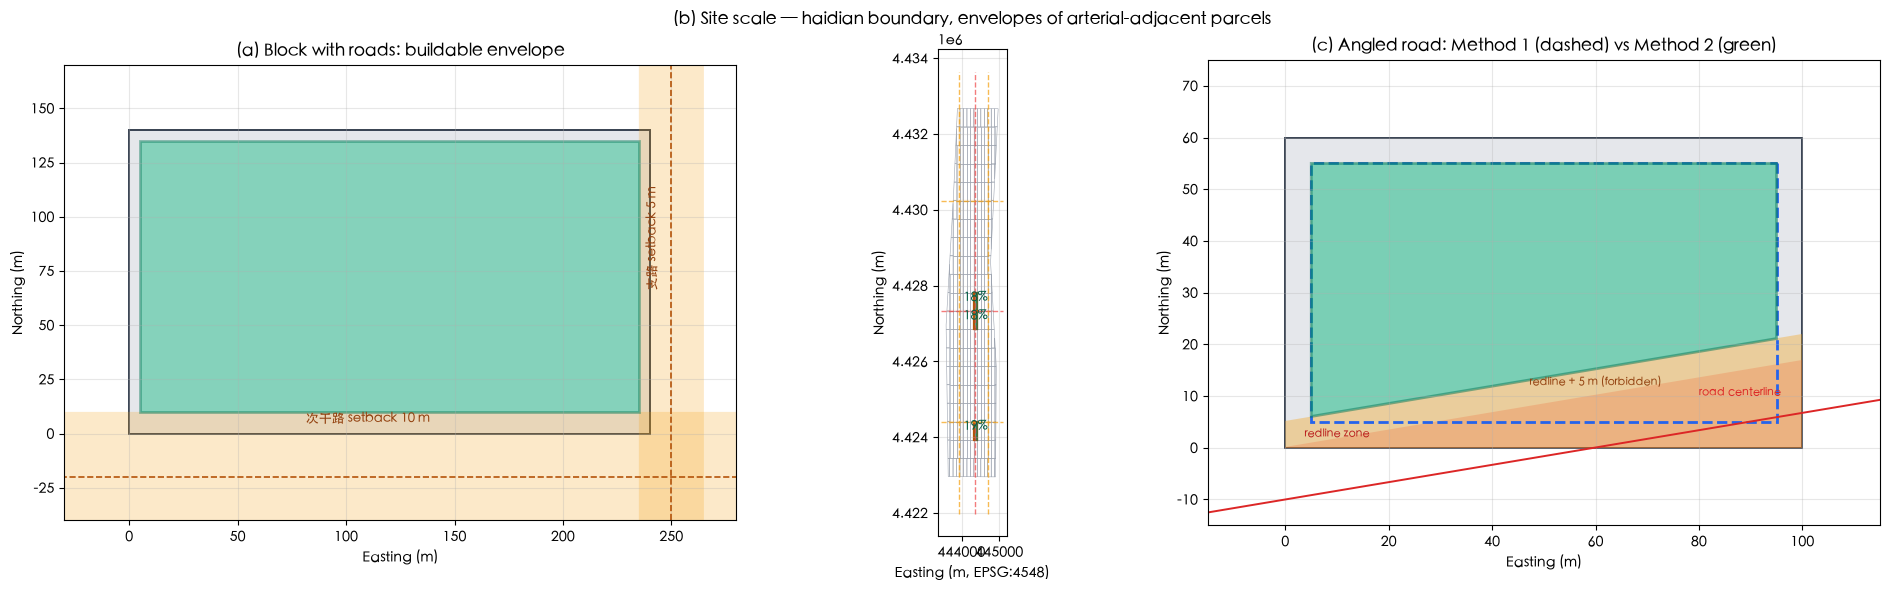

Saved ../outputs/14-method2-road-network.png


In [8]:
# ---- Figure 2: Method 2 — road-network-aware envelopes ----
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# --- Panel (a): synthetic block close-up ---
ax = axes[0]
ax.add_patch(MPLPolygon(list(block.exterior.coords), facecolor='#e5e7eb', edgecolor='#374151', lw=1.4))
for ln, cls, color in [(sec_center, 'secondary', '#f59e0b'), (loc_center, 'local', '#f59e0b')]:
    hw = ROAD_CLASS_PARAMS[cls]['half_width']
    sb = ROAD_CLASS_PARAMS[cls]['setback']
    ax.add_patch(MPLPolygon(list(ln.buffer(hw + sb).intersection(box(-50, -50, 300, 200)).exterior.coords),
                            facecolor='#f59e0b', alpha=0.22, edgecolor='none'))
    xs, ys = ln.xy
    ax.plot(xs, ys, '--', color='#b45309', lw=1.2)
ax.add_patch(MPLPolygon(list(envelope.exterior.coords), facecolor='#10b981',
                        alpha=0.45, edgecolor='#047857', lw=2))
ax.set_aspect('equal')
ax.set_xlim(-30, 280); ax.set_ylim(-40, 170)
ax.set_title('(a) Block with roads: buildable envelope', fontsize=12, fontweight='bold')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.annotate('次干路 setback 10 m', xy=(110, 5), fontsize=9, color='#92400e', ha='center')
ax.annotate('支路 setback 5 m', xy=(238, 90), fontsize=9, color='#92400e', rotation=90, va='center')

# --- Panel (b): site scale ---
ax = axes[1]
for p in parcels:
    ax.add_patch(MPLPolygon(list(p.exterior.coords), facecolor='none', edgecolor='#9ca3af', lw=0.4))
for name, cls, ln in site_roads:
    color = '#ef4444' if cls == 'arterial' else '#f59e0b'
    hw = ROAD_CLASS_PARAMS[cls]['half_width']
    zone = ln.buffer(hw).intersection(boundary_4548)
    ax.add_patch(MPLPolygon(list(zone.exterior.coords), facecolor=color, alpha=0.15, edgecolor='none'))
    xs, ys = ln.xy
    ax.plot(xs, ys, ls='--', color=color, lw=1.0, alpha=0.7)
# 3 sample parcels adjacent to the arterial + their envelopes
arterial_zone = unary_union([ln.buffer(30.0) for name, cls, ln in site_roads if cls == 'arterial'])
overlaps = [(i, parcels[i].intersection(arterial_zone).area) for i in range(len(parcels))]
sample_idx = sorted(overlaps, key=lambda t: -t[1])[:3]
for i, _ in sample_idx:
    ax.add_patch(MPLPolygon(list(parcels[i].exterior.coords), facecolor='none',
                            edgecolor='#b45309', lw=1.6))
    if buildables[i] is not None:
        ax.add_patch(MPLPolygon(list(buildables[i].exterior.coords), facecolor='#10b981',
                                alpha=0.55, edgecolor='#047857', lw=1.6))
        ax.annotate(f'{buildables[i].area/parcels[i].area*100:.0f}%',
                    (parcels[i].centroid.x, parcels[i].centroid.y), fontsize=9,
                    color='#065f46', ha='center')
ax.set_aspect('equal')
ax.set_title('(b) Site scale — haidian boundary, envelopes of arterial-adjacent parcels', fontsize=12, fontweight='bold')
ax.set_xlabel('Easting (m, EPSG:4548)'); ax.set_ylabel('Northing (m)')

# --- Panel (c): angled road — Method 1 vs Method 2 ---
ax = axes[2]
ax.add_patch(MPLPolygon(list(parcel2.exterior.coords), facecolor='#e5e7eb', edgecolor='#374151', lw=1.4))
ax.add_patch(MPLPolygon(list(redline.intersection(parcel2).exterior.coords),
                        facecolor='#ef4444', alpha=0.25, edgecolor='none'))
ax.add_patch(MPLPolygon(list(forbidden.intersection(parcel2).exterior.coords),
                        facecolor='#f59e0b', alpha=0.35, edgecolor='none'))
xs, ys = cl.xy
ax.plot(xs, ys, '-', color='#dc2626', lw=1.4)
ax.add_patch(MPLPolygon(list(env_m1_angled.exterior.coords), facecolor='none',
                        edgecolor='#2563eb', lw=2.0, ls='--'))
ax.add_patch(MPLPolygon(list(env_m2_angled.exterior.coords), facecolor='#10b981',
                        alpha=0.5, edgecolor='#047857', lw=2.0))
ax.annotate('road centerline', xy=(80, 10), fontsize=8, color='#dc2626')
ax.annotate('redline zone', xy=(10, 2), fontsize=8, color='#b91c1c', ha='center')
ax.annotate('redline + 5 m (forbidden)', xy=(60, 12), fontsize=8, color='#92400e', ha='center')
ax.set_aspect('equal')
ax.set_xlim(-15, 115); ax.set_ylim(-15, 75)
ax.set_title('(c) Angled road: Method 1 (dashed) vs Method 2 (green)', fontsize=12, fontweight='bold')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')

plt.tight_layout()
plt.savefig('../outputs/14-method2-road-network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../outputs/14-method2-road-network.png')


## 3. Method 3: Building Footprint Generator with Setbacks

With the buildable envelope in hand, we can now generate **feasible building
footprints** — the same task as notebook 03, but the generator is constrained by
the envelope instead of being clipped to the raw parcel. This guarantees every
footprint automatically respects all setbacks.

**Generation rules**:
- **Orientation** — south-facing preference (住宅朝南): the long axis runs E-W
  (85% of placements), occasional N-S slabs for variety.
- **Aspect ratio limits** — slab depth/width must be within [0.35, 1.0]
  (typical 1:2 to 1:2.5 slabs), enforced on the palette.
- **Spacing** — minimum clear distance between footprints (fire separation,
  6 m target; ±0.3 m placement jitter keeps the guarantee at >= 5.4 m).
- **Coverage target** — stop when the covered footprint area reaches the
  target fraction of the parcel.

We generate two versions: on the raw parcel (notebook 03 behaviour) and inside
the setback envelope, then compare coverage and FAR (容积率).


In [9]:
# Building palette: (building_type, width, depth, floors) — aspect ratios within [0.35, 1.0]
PALETTE = [
    ('residential_slab',     30.0, 12.0, 6),   # d/w = 0.40 (1:2.5 slab)
    ('residential_slab_slim', 24.0, 11.0, 6),  # d/w = 0.46 (1:2.2 slab)
    ('residential_tower',    22.0, 22.0, 12),  # d/w = 1.00 (tower)
]
for btype, w, d, fl in PALETTE:
    ratio = d / w
    assert 0.35 <= ratio <= 1.0, f'aspect ratio {ratio:.2f} out of limits for {btype}'
print('Palette aspect ratios:', [f'{p[2]/p[1]:.2f}' for p in PALETTE], 'within [0.35, 1.0]')


def generate_footprints(envelope, palette, spacing, target_coverage, parcel_area,
                        rng, p_south=0.85, jitter=0.3, max_tries=8000):
    """Place rectangular footprints inside `envelope` on a jittered grid.

    Returns (placed, covered) where placed = [(rect, angle, btype, floors)].
    South-facing preference: angle 0 means the long axis runs E-W.
    Spacing: min clear distance between footprints (fire separation).
    """
    sx, sy = spacing
    minx, miny, maxx, maxy = envelope.bounds
    wmax = max(p[1] for p in palette)
    dmax = max(p[2] for p in palette)
    target_area = target_coverage * parcel_area

    placed = []
    placed_buffers = []
    covered = 0.0
    tries = 0
    # Note: jitter must be applied to copies — mutating the loop variable would
    # let it drift across columns (a random walk) and break the spacing guarantee.
    for cy0 in np.arange(miny + dmax / 2 + jitter, maxy - dmax / 2, dmax + sy):
        for cx0 in np.arange(minx + wmax / 2 + jitter, maxx - wmax / 2, wmax + sx):
            if covered >= target_area or tries >= max_tries:
                break
            tries += 1
            cx = cx0 + rng.uniform(-jitter, jitter)
            cy = cy0 + rng.uniform(-jitter, jitter)
            btype, w, d, floors = palette[rng.integers(0, len(palette))]
            angs = [0.0] if rng.random() < p_south else [90.0]
            for ang in angs:
                if ang == 0.0:
                    rect = box(cx - w / 2, cy - d / 2, cx + w / 2, cy + d / 2)
                else:
                    rect = box(cx - d / 2, cy - w / 2, cx + d / 2, cy + w / 2)
                if not envelope.buffer(-0.05).covers(rect):
                    continue
                if any(rect.intersects(buff) for buff in placed_buffers):
                    continue
                placed.append((rect, ang, btype, floors))
                placed_buffers.append(rect.buffer(min(sx, sy) / 2))
                covered += rect.area
                break
        if covered >= target_area:
            break
    return placed, covered


def validate_footprints(placed, envelope, spacing, jitter=0.3):
    """Containment + pairwise spacing check. Returns (issues, min_gap)."""
    issues = 0
    min_gap = float('inf')
    for i in range(len(placed)):
        rect = placed[i][0]
        if not envelope.buffer(-0.05).covers(rect):
            issues += 1
        for j in range(i + 1, len(placed)):
            min_gap = min(min_gap, rect.distance(placed[j][0]))
    return issues, min_gap


def summarize(placed, parcel_area, label):
    n = len(placed)
    area = sum(p[0].area for p in placed)
    far = sum(p[0].area * p[3] for p in placed) / parcel_area
    print(f'{label}: {n} footprints, footprint area {area:7.0f} m², '
          f'coverage {area / parcel_area * 100:5.1f}%, FAR {far:5.2f} (floors-weighted)')
    return n, area, far


rng = np.random.default_rng(42)
print('=== Footprint generation (residential block 240 x 140 m) ===')

# BEFORE: notebook-03 style — footprints on the raw parcel (no setbacks)
placed_before, covered_before = generate_footprints(
    block, PALETTE, (6.0, 6.0), target_coverage=1.0, parcel_area=block.area, rng=rng)
n_before, area_before, far_before = summarize(placed_before, block.area, 'BEFORE (raw parcel)')

# AFTER: footprints inside the setback envelope
placed_after, covered_after = generate_footprints(
    envelope, PALETTE, (6.0, 6.0), target_coverage=1.0, parcel_area=block.area, rng=rng)
n_after, area_after, far_after = summarize(placed_after, block.area, 'AFTER  (setback envelope)')

print()
print(f'Envelope / parcel ratio: {envelope.area / block.area * 100:.1f}%')
print(f'Coverage reduction:      {area_before / block.area * 100 - area_after / block.area * 100:.1f} pp')
print(f'FAR reduction:           {far_before - far_after:.2f} ({(far_before - far_after) / far_before * 100:.0f}%)')

# Validation
issues_b, gap_b = validate_footprints(placed_before, block, (6.0, 6.0))
issues_a, gap_a = validate_footprints(placed_after, envelope, (6.0, 6.0))
print()
print('=== Validation ===')
print(f'BEFORE: containment issues {issues_b}, min pairwise gap {gap_b:.2f} m (target >= 5.4 m)')
print(f'AFTER:  containment issues {issues_a}, min pairwise gap {gap_a:.2f} m (target >= 5.4 m)')


Palette aspect ratios: ['0.40', '0.46', '1.00'] within [0.35, 1.0]
=== Footprint generation (residential block 240 x 140 m) ===
BEFORE (raw parcel): 30 footprints, footprint area   11700 m², coverage  34.8%, FAR  3.39 (floors-weighted)
AFTER  (setback envelope): 23 footprints, footprint area    8736 m², coverage  26.0%, FAR  2.08 (floors-weighted)

Envelope / parcel ratio: 85.6%
Coverage reduction:      8.8 pp
FAR reduction:           1.31 (39%)

=== Validation ===
BEFORE: containment issues 0, min pairwise gap 5.69 m (target >= 5.4 m)
AFTER:  containment issues 0, min pairwise gap 5.53 m (target >= 5.4 m)


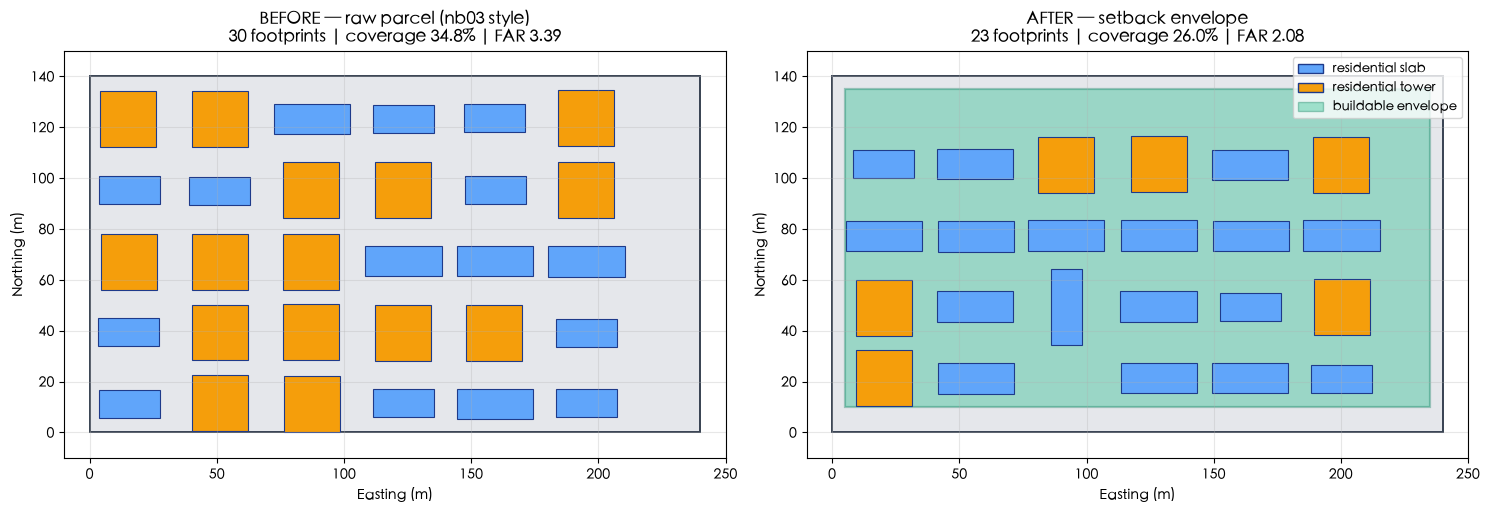

Saved ../outputs/14-method3-footprints.png


In [10]:
# ---- Figure 3: footprints before vs after setbacks ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

for ax, env, placed, title, cov, far in [
    (axes[0], block, placed_before, 'BEFORE — raw parcel (nb03 style)', area_before / block.area, far_before),
    (axes[1], envelope, placed_after, 'AFTER — setback envelope', area_after / block.area, far_after),
]:
    ax.add_patch(MPLPolygon(list(block.exterior.coords), facecolor='#e5e7eb',
                            edgecolor='#374151', lw=1.4))
    if env is envelope:
        ax.add_patch(MPLPolygon(list(envelope.exterior.coords), facecolor='#10b981',
                                alpha=0.35, edgecolor='#047857', lw=1.6))
    for rect, ang, btype, floors in placed:
        color = '#60a5fa' if btype.startswith('residential_slab') else '#f59e0b'
        ax.add_patch(MPLPolygon(list(rect.exterior.coords), facecolor=color,
                                edgecolor='#1e3a8a', lw=0.8))
    ax.set_aspect('equal')
    ax.set_xlim(-10, 250); ax.set_ylim(-10, 150)
    ax.set_title(f'{title}\n{len(placed)} footprints | coverage {cov*100:.1f}% | FAR {far:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')

handles = [
    mpatches.Patch(facecolor='#60a5fa', edgecolor='#1e3a8a', label='residential slab'),
    mpatches.Patch(facecolor='#f59e0b', edgecolor='#1e3a8a', label='residential tower'),
    mpatches.Patch(facecolor='#10b981', alpha=0.35, edgecolor='#047857', label='buildable envelope'),
]
axes[1].legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/14-method3-footprints.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../outputs/14-method3-footprints.png')


In [11]:
# ---- Export footprints as GeoJSON (EPSG:4548) ----
rows = []
for rect, ang, btype, floors in placed_after:
    rows.append({
        'geometry': rect,
        'parcel_id': 'BLK-240x140-R',
        'land_use': 'R',
        'building_type': btype,
        'floors': int(floors),
        'height_m': round(floors * 3.0, 1),
        'footprint_area_m2': round(rect.area, 1),
        'orientation_deg': int(ang),
        'respects_setbacks': True,
    })
gdf_fp = gpd.GeoDataFrame(rows, crs=CRS_4548)
gdf_fp.to_file('../outputs/14-footprints.geojson', driver='GeoJSON')
print(f'Exported {len(gdf_fp)} footprints -> ../outputs/14-footprints.geojson (EPSG:4548)')
print()
print(gdf_fp[['building_type', 'floors', 'height_m', 'footprint_area_m2',
              'orientation_deg']].head(8).to_string(index=False))

# Every footprint keeps the required distance from both redlines
sec_redline = sec_center.buffer(20.0)
loc_redline = loc_center.buffer(10.0)
d_sec = min(r.distance(sec_redline) for r, *_ in placed_after)
d_loc = min(r.distance(loc_redline) for r, *_ in placed_after)
print()
print(f'Min distance from footprints to secondary redline: {d_sec:.2f} m (require >= 10 m)')
print(f'Min distance from footprints to local redline:     {d_loc:.2f} m (require >= 5 m)')


Exported 23 footprints -> ../outputs/14-footprints.geojson (EPSG:4548)



        building_type  floors  height_m  footprint_area_m2  orientation_deg
    residential_tower      12      36.0              484.0                0
     residential_slab       6      18.0              360.0                0
     residential_slab       6      18.0              360.0                0
     residential_slab       6      18.0              360.0                0
residential_slab_slim       6      18.0              264.0                0
    residential_tower      12      36.0              484.0                0
     residential_slab       6      18.0              360.0                0
     residential_slab       6      18.0              360.0               90

Min distance from footprints to secondary redline: 10.27 m (require >= 10 m)
Min distance from footprints to local redline:     24.78 m (require >= 5 m)


## 4. Comparison and Conclusions

### Method comparison

| Method | Input | Constraint source | Cost | When to use |
|---|---|---|---|---|
| 1. Buffer offsets | parcel + per-edge setbacks | parcel edge itself | O(edges) | Simple lots, redline coincides with the edge |
| 2. Road-network-aware | centerlines + classes + parcel | redline in space | O(roads · parcel) | Real sites — angled/curved roads, multiple classes |
| 3. Footprint generator | envelope + palette + spacing | envelope + fire separation | O(candidates) | Design generation (replaces nb03 clipping) |

**When does the difference matter?**
- **Always for real networks** — redlines rarely coincide exactly with parcel
  edges at corners; Method 1 under-constrains by up to the redline's intrusion.
- **Corner parcels** — two road constraints compound; only Method 2 handles the
  wedge-shaped forbidden zones correctly.
- **Curved roads** — per-edge offsets cannot represent a curved constraint at
  all; buffering handles it naturally.
- **When it does NOT matter** — axis-aligned lots where the redline is the
  parcel edge (verified above: symmetric difference < 1e-6 m²).

### Impact of setbacks on site capacity

The sweep below varies the secondary-road setback on the demo block and reports
the envelope ratio and the achievable FAR (floors-weighted, footprint-limited,
ignoring 日照间距 for now — real residential FAR is much lower once solar
spacing from notebook 10 is applied).

Note the **grid quantization effect**: footprints sit on a fixed grid, so a
setback strip only changes the count once it consumes a whole row or column of
the grid. The envelope ratio is the continuous capacity ceiling; the discrete
count steps down underneath it.


In [12]:
# ---- Capacity sensitivity: road setback depth on the demo block ----
scenarios = [
    ('S0 none',            False, 0.0, 0.0),
    ('S1 property 5m',     False, 0.0, 5.0),
    ('S2 +local 5m',       True,  0.0, 5.0),
    ('S3 +secondary 10m',  True, 10.0, 5.0),
    ('S4 +secondary 15m',  True, 15.0, 5.0),
]
rows = []
for name, has_roads, d_sec, d_prop in scenarios:
    if has_roads:
        cons = unary_union([
            LineString([(-40, -20), (280, -20)]).buffer(20.0 + d_sec),  # secondary, south
            LineString([(250, -40), (250, 180)]).buffer(10.0 + 5.0),    # local, east
        ])
    else:
        cons = Polygon()
    env = buildable_from_roads(block, cons, d_prop)
    ratio = 0.0 if env is None else env.area / block.area
    if env is None or env.area < 100:
        rows.append((name, ratio, 0, 0.0, 0.0))
        continue
    placed, covered = generate_footprints(env, PALETTE, (6.0, 6.0),
                                          target_coverage=1.0, parcel_area=block.area,
                                          rng=np.random.default_rng(7))
    n = len(placed)
    area = sum(p[0].area for p in placed)
    far = sum(p[0].area * p[3] for p in placed) / block.area
    rows.append((name, ratio, n, area / block.area, far))

print('=== Capacity sensitivity (block 240 x 140 m) ===')
print(f'{"scenario":<18}{"env/parcel":>10}{"footprints":>11}{"coverage":>10}{"FAR":>8}{"FAR ceiling":>12}')
base_far = rows[0][4]
for name, ratio, n, cov, far in rows:
    # Continuous ceiling: what FAR would the envelope support if packed at S0's
    # footprint efficiency? (grid quantization keeps the discrete count lower)
    ceiling = ratio * base_far
    print(f'{name:<18}{ratio:10.3f}{n:11d}{cov:10.3f}{far:8.2f}{ceiling:12.2f}')

print()
print('Note: the footprint count is grid-quantized — a setback strip must consume')
print('a whole grid row/column before the count drops. The FAR ceiling column')
print('(envelope ratio x S0 FAR) is the continuous capacity bound.')


=== Capacity sensitivity (block 240 x 140 m) ===
scenario          env/parcel footprints  coverage     FAR FAR ceiling
S0 none                1.000         28     0.283    2.30        2.30
S1 property 5m         0.890         22     0.223    1.77        2.05
S2 +local 5m           0.890         22     0.223    1.77        2.05
S3 +secondary 10m      0.856         22     0.223    1.77        1.97
S4 +secondary 15m      0.821         22     0.223    1.77        1.89

Note: the footprint count is grid-quantized — a setback strip must consume
a whole grid row/column before the count drops. The FAR ceiling column
(envelope ratio x S0 FAR) is the continuous capacity bound.


findfont: Failed to find font weight bold, now using 400.


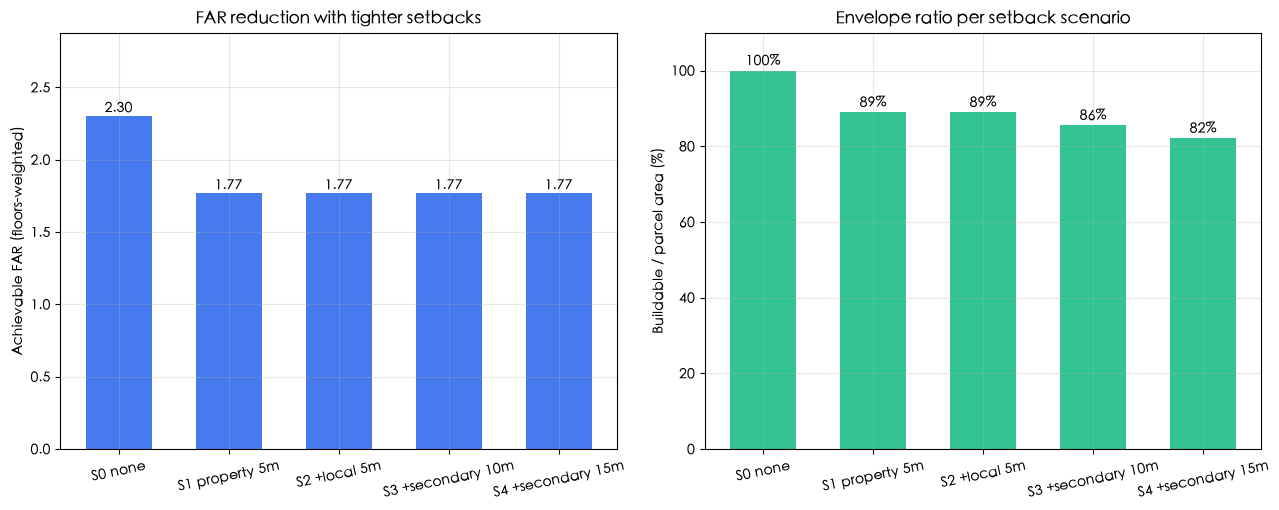

Saved ../outputs/14-method4-capacity-impact.png


In [13]:
# ---- Figure 4: setback impact on capacity ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

names = [r[0] for r in rows]
far_vals = [r[4] for r in rows]
ratio_vals = [r[1] for r in rows]

bars1 = ax1.bar(names, far_vals, color='#2563eb', alpha=0.85, width=0.6)
for bar, v in zip(bars1, far_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}',
             ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Achievable FAR (floors-weighted)')
ax1.set_title('FAR reduction with tighter setbacks', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(far_vals) * 1.25)
ax1.tick_params(axis='x', rotation=12)

bars2 = ax2.bar(names, [r * 100 for r in ratio_vals], color='#10b981', alpha=0.85, width=0.6)
for bar, v in zip(bars2, ratio_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, v * 100 + 1.2, f'{v*100:.0f}%',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Buildable / parcel area (%)')
ax2.set_title('Envelope ratio per setback scenario', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.savefig('../outputs/14-method4-capacity-impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../outputs/14-method4-capacity-impact.png')


### Integration into the building-generation pipeline (notebook 03)

Notebook 03 generated footprints by grid placement **clipped to the raw
parcel** — buildings could touch the parcel edge or the redline. The correct
pipeline is:

```
parcel boundary
   │  Method 2 (this notebook): redlines -> constraint zones
   ▼
buildable envelope          <- setback-respecting
   │  Method 3: grid placement + south orientation + fire separation
   ▼
footprints (GeoJSON)        <- every footprint satisfies all setbacks
```

The only change to notebook 03's machinery is the placement polygon: clip to
the envelope instead of the parcel. The envelope is the reusable primitive —
it should live in `src/generation.py` as `buildable_envelope(parcel, roads, ...)`
next to `subdivide_boundary`.

### Key takeaways

1. **The redline, not the parcel edge, is the constraint.** Method 1 is only
   valid when they coincide; the angled-road test showed a 16.75 m redline
   intrusion under-cutting the naive envelope by ~15 m of required setback.
2. **Method 2 is the CAD/GIS-standard construction** — buffer the centerline by
   redline half-width + class setback, union the zones, subtract from the
   property-setback-shrunk parcel. O(roads) for any site.
3. **Setbacks cost real capacity.** On the demo block the achieved FAR dropped
   by roughly a fifth at the footprint level (numbers printed above); site-scale,
   the mean buildable/parcel ratio printed in section 2 gives the first-order
   estimate: notebook 06's density 21.81% and FAR 2.07 scale by that ratio for
   a typical grid network.
4. **Spacing dominates residential capacity.** Fire separation (6–13 m) and
   日照间距 (D/H 1.6–1.7, notebook 10) remove far more floor area than redline
   setbacks alone — setbacks are the *first* constraint applied, not the last.
5. **Every rule is data** — all setbacks are parameters (road class table,
   property table, palette); swap in the 控规 values and the whole pipeline
   recomputes. Nothing is hard-coded.


## 5. Inter-Building Fire Separation (建筑防火间距) — GB 50016-2014

Sections 1–3 constrained buildings from **roads** (redlines). This depth
extension adds the second spatial constraint: the **minimum clear distance
between buildings** (防火间距). Every building must keep both its road
setbacks and its fire separation from every neighbour.

**Requirements (typical reference values, GB 50016-2014):**

| Fire resistance grade | Minimum separation |
|---|---|
| Grade 1–2 (一、二级) | 6 m |
| Grade 3 (三级) | 9 m |
| Grade 4 (四级) | 13 m |
| High-rise residential (> 27 m, or > 8 storeys) | ≥ 13 m from ANY building |

**Three methods:**

1. **Pairwise distance** — exact: for every pair of footprints compute the
   minimum distance (shapely) and flag pairs below their pair's requirement.
   O(N²) but authoritative.
2. **Buffer intersection** — each building is buffered by *half* its required
   separation; two buildings are too close iff their zones intersect. Exact
   when both buildings share one grade (sum of half-zones = requirement);
   with mixed grades the sum of half-zones ≤ requirement, so the zone test
   can only *miss* violations — never invent them. Easier to visualize.
3. **Combined setback + fire** — a building must satisfy BOTH road redline
   setbacks (sections 1–2) AND inter-building fire separation; for each pair
   the more restrictive constraint is the binding one.

All three run on the Section-3 layout (23 footprints inside the setback
envelope) and on the raw-parcel layout (before), then the result is drawn.


In [14]:
# ---- Fire-separation machinery extracted to src/setback.py ----
from src.setback import (
    DEFAULT_FIRE_GRADE, check_fire_separation, fire_grade_of,
    fire_separation_buffer, required_fire_separation,
)

def footprints_to_buildings(placed):
    """(rect, ang, btype, floors) -> (footprints, {idx: fire grade})."""
    buildings = [rect for rect, ang, btype, floors in placed]
    grade_map = {i: fire_grade_of(floors=floors)
                 for i, (rect, ang, btype, floors) in enumerate(placed)}
    return buildings, grade_map

bld_after, grade_after = footprints_to_buildings(placed_after)
bld_before, grade_before = footprints_to_buildings(placed_before)

from collections import Counter
print('=== Fire grade classification (AFTER layout: 23 footprints) ===')
for g, n in sorted(Counter(grade_after.values()).items(), key=str):
    print(f'  grade {g}: {n} buildings')
print('slabs (6 storeys -> 18 m) are Grade 2 -> 6 m; towers (12 storeys -> 36 m)')
print('are high-rise residential -> 13 m from any building')
print()

# ---- Method 1: exact pairwise distance check ----
res_after = check_fire_separation(bld_after, grade_after)
res_before = check_fire_separation(bld_before, grade_before)
print('=== Method 1: pairwise distance check (exact, O(N^2)) ===')
for label, res in [('AFTER  (setback envelope)', res_after),
                   ('BEFORE (raw parcel)', res_before)]:
    print(f'{label}: {res["n_buildings"]:2d} buildings, {res["n_pairs"]:3d} pairs, '
          f'{res["n_violations"]:3d} violations, min distance {res["min_distance"]:5.2f} m')
print()
worst = sorted(res_after['violations'],
               key=lambda v: v['required'] - v['distance'], reverse=True)[:8]
print('Worst violations in the AFTER layout (required - actual):')
for v in worst:
    print(f'  #{v["i"]:2d}-#{v["j"]:2d}: {v["distance"]:5.2f} m  <  required {v["required"]:4.0f} m '
          f'(grade {v["grade_i"]} vs {v["grade_j"]})')
print()
print('Note: the Section-3 generator enforces spacing >= 6 m - 0.3 m jitter = 5.4 m.')
print('That floor is below the 6 m slab rule, and the towers (13 m from anything)')
print('sit far closer than 13 m to their neighbours -> the layout is NOT compliant.')

=== Fire grade classification (AFTER layout: 23 footprints) ===
  grade high_rise: 6 buildings
  grade 2: 17 buildings
slabs (6 storeys -> 18 m) are Grade 2 -> 6 m; towers (12 storeys -> 36 m)
are high-rise residential -> 13 m from any building

=== Method 1: pairwise distance check (exact, O(N^2)) ===
AFTER  (setback envelope): 23 buildings, 253 pairs,  16 violations, min distance  5.53 m
BEFORE (raw parcel): 30 buildings, 435 pairs,  26 violations, min distance  5.69 m

Worst violations in the AFTER layout (required - actual):
  # 0-# 5:  5.82 m  <  required   13 m (grade high_rise vs high_rise)
  #20-#21:  9.86 m  <  required   13 m (grade high_rise vs 2)
  #18-#19:  9.87 m  <  required   13 m (grade 2 vs high_rise)
  # 5-# 6:  9.90 m  <  required   13 m (grade high_rise vs 2)
  #21-#22:  9.91 m  <  required   13 m (grade 2 vs high_rise)
  # 0-# 1: 10.11 m  <  required   13 m (grade high_rise vs 2)
  #16-#22: 10.56 m  <  required   13 m (grade 2 vs high_rise)
  #13-#19: 10.86 m  <  

In [15]:
# ---- Method 2: half-distance buffer zones ----
def buffer_zone_check(buildings, grade_map):
    """Flag pairs whose half-separation buffer zones intersect.

    Returns (zones, flagged_pairs).  Zone radius = half the requirement of
    the building's grade against a default (Grade 2) peer.
    """
    zones = [fire_separation_buffer(b, grade_map.get(i, DEFAULT_FIRE_GRADE))
             for i, b in enumerate(buildings)]
    flagged = set()
    for i in range(len(buildings)):
        for j in range(i + 1, len(buildings)):
            if zones[i].intersects(zones[j]):
                flagged.add((i, j))
    return zones, flagged

zones_after, buf_flagged = buffer_zone_check(bld_after, grade_after)
pair_flagged = {(v['i'], v['j']) for v in res_after['violations']}
missed = sorted(pair_flagged - buf_flagged)   # zone test misses
extra = sorted(buf_flagged - pair_flagged)    # zone test over-flags

print('=== Method 2: buffer-intersection check (AFTER layout) ===')
print(f'Zone-flagged pairs: {len(buf_flagged):3d}   '
      f'exact pairwise violations: {res_after["n_violations"]:3d}')
print(f'Zone test misses:    {len(missed):3d} pairs   over-flags: {len(extra)}')
if missed:
    i, j = missed[0]
    r = required_fire_separation(grade_after.get(i, DEFAULT_FIRE_GRADE),
                                 grade_after.get(j, DEFAULT_FIRE_GRADE))
    r_i = required_fire_separation(grade_after.get(i, DEFAULT_FIRE_GRADE),
                                   DEFAULT_FIRE_GRADE) / 2
    r_j = required_fire_separation(grade_after.get(j, DEFAULT_FIRE_GRADE),
                                   DEFAULT_FIRE_GRADE) / 2
    print(f'  sample miss #{i}-#{j}: distance {bld_after[i].distance(bld_after[j]):.2f} m '
          f'< required {r:.0f} m, but half-zones sum only {r_i + r_j:.1f} m')
print()

# Uniform-grade sanity check: on the slab-only subset the methods agree exactly
slab_idx = [i for i, g in grade_after.items() if g == DEFAULT_FIRE_GRADE]
slab_map = {k: DEFAULT_FIRE_GRADE for k in range(len(slab_idx))}
slab_blds = [bld_after[i] for i in slab_idx]
res_slab = check_fire_separation(slab_blds, slab_map)
_, slab_flagged = buffer_zone_check(slab_blds, slab_map)
agree = slab_flagged == {(v['i'], v['j']) for v in res_slab['violations']}
print(f'Uniform-grade subset ({len(slab_idx)} Grade-2 slabs): pairwise '
      f'{res_slab["n_violations"]} violations, zone test {len(slab_flagged)} '
      f'-> methods agree exactly: {agree}')

=== Method 2: buffer-intersection check (AFTER layout) ===
Zone-flagged pairs:   4   exact pairwise violations:  16
Zone test misses:     12 pairs   over-flags: 0
  sample miss #0-#1: distance 10.11 m < required 13 m, but half-zones sum only 9.5 m

Uniform-grade subset (17 Grade-2 slabs): pairwise 3 violations, zone test 3 -> methods agree exactly: True


In [16]:
# ---- Method 3: combined road-setback + fire-separation check ----
# Redline zones of the demo block (Section 2): secondary redline at y = 0
# (setback 10 m), local redline at x = 240 (setback 5 m).
ROAD_ZONES = [
    (sec_center.buffer(20.0), 'secondary', 10.0),   # redline strip, top edge y = 0
    (loc_center.buffer(10.0), 'local',      5.0),    # redline strip, left edge x = 240
]

def road_setback_violations(buildings):
    """Buildings whose footprint reaches inside a redline setback zone."""
    bad = []
    for i, b in enumerate(buildings):
        for redline, cls, setback in ROAD_ZONES:
            d = b.distance(redline)
            if d < setback - 1e-9:
                bad.append((i, cls, setback, d))
    return bad

road_bad_before = road_setback_violations(bld_before)
road_bad_after = road_setback_violations(bld_after)
print('=== Method 3: combined road setback + fire separation ===')
print(f'Road-setback violations  BEFORE (raw parcel): {len(road_bad_before)}')
for i, cls, sb, d in road_bad_before[:6]:
    print(f'  #{i}: {d:5.2f} m from {cls} redline (required >= {sb:.0f} m)')
print(f'Road-setback violations  AFTER  (setback envelope): {len(road_bad_after)}  '
      f'<- envelope guarantees this by construction')
print()

def combined_violations(buildings, grade_map):
    """Pairs failing fire separation, pairs with a road-failing building,
    and their union — a pair is compliant only if BOTH constraints hold."""
    fire = check_fire_separation(buildings, grade_map)
    road_fail = {i for i, *_ in road_setback_violations(buildings)}
    n_road_pairs = sum(1 for i in range(len(buildings))
                       for j in range(i + 1, len(buildings))
                       if i in road_fail or j in road_fail)
    return fire['n_violations'], n_road_pairs, fire['n_violations'] + n_road_pairs

fb, rb, cb = combined_violations(bld_before, grade_before)
fa, ra, ca = combined_violations(bld_after, grade_after)
print(f'{"layout":<26}{"fire pairs":>12}{"road pairs":>12}{"combined":>12}')
print(f'{"BEFORE (raw parcel)":<26}{fb:>12}{rb:>12}{cb:>12}')
print(f'{"AFTER (setback envelope)":<26}{fa:>12}{ra:>12}{ca:>12}')
print()
print('Binding constraint: the setback envelope removed every road failure,')
print('so in the AFTER layout fire separation is the ONLY (and binding)')
print('constraint left — inter-building spacing, not roads, caps this layout.')

=== Method 3: combined road setback + fire separation ===
Road-setback violations  BEFORE (raw parcel): 6
  #0:  5.76 m from secondary redline (required >= 10 m)
  #1:  0.59 m from secondary redline (required >= 10 m)
  #2:  0.08 m from secondary redline (required >= 10 m)
  #3:  5.89 m from secondary redline (required >= 10 m)
  #4:  5.14 m from secondary redline (required >= 10 m)
  #5:  5.88 m from secondary redline (required >= 10 m)
Road-setback violations  AFTER  (setback envelope): 0  <- envelope guarantees this by construction

layout                      fire pairs  road pairs    combined
BEFORE (raw parcel)                 26         159         185
AFTER (setback envelope)            16           0          16

Binding constraint: the setback envelope removed every road failure,
so in the AFTER layout fire separation is the ONLY (and binding)
constraint left — inter-building spacing, not roads, caps this layout.


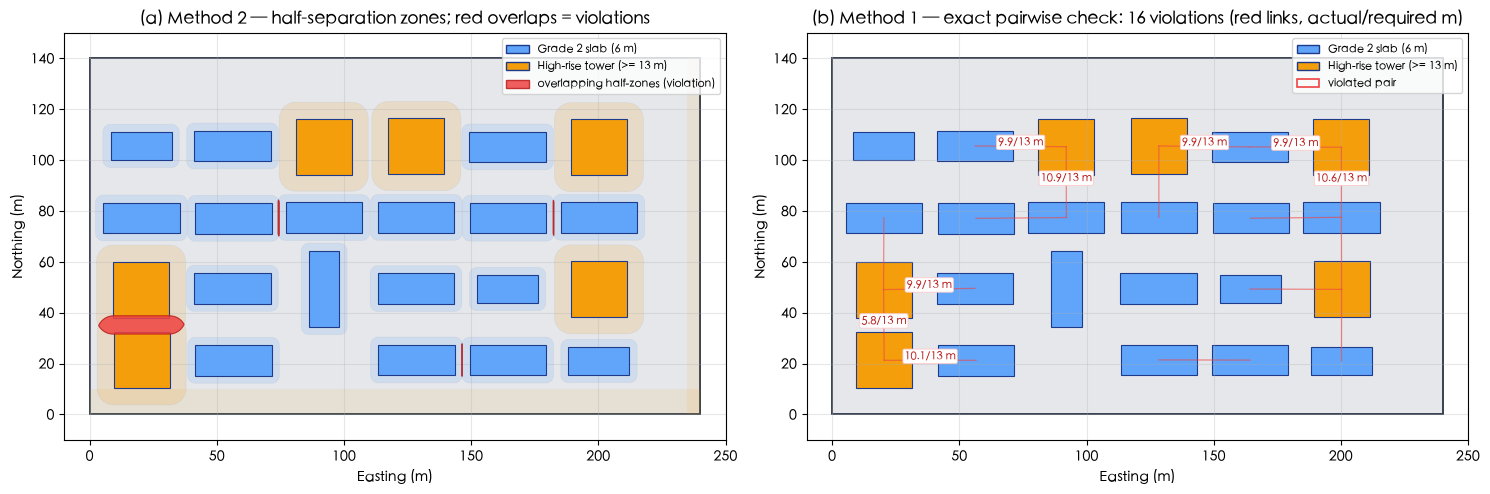

Saved ../outputs/14-fire-separation.png


In [17]:
# ---- Figure 5: fire separation — buffer zones + violations highlighted ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

def FOOT_COLOR(btype):
    return '#60a5fa' if btype.startswith('residential_slab') else '#f59e0b'

# --- Panel (a): Method 2 — half-separation zones, overlaps = violations ---
ax = axes[0]
ax.add_patch(MPLPolygon(list(block.exterior.coords), facecolor='#e5e7eb',
                        edgecolor='#374151', lw=1.4))
for redline, cls, setback in ROAD_ZONES:
    zone = redline.buffer(setback).intersection(block)
    ax.add_patch(MPLPolygon(list(zone.exterior.coords), facecolor='#f59e0b',
                            alpha=0.10, edgecolor='none'))
for i, z in enumerate(zones_after):
    ax.add_patch(MPLPolygon(list(z.exterior.coords),
                            facecolor=FOOT_COLOR(placed_after[i][2]), alpha=0.16,
                            edgecolor='#94a3b8', lw=0.5))
overlap = unary_union([zones_after[i].intersection(zones_after[j])
                       for i, j in buf_flagged])
if not overlap.is_empty:
    parts = overlap.geoms if overlap.geom_type == 'MultiPolygon' else [overlap]
    for part in parts:
        ax.add_patch(MPLPolygon(list(part.exterior.coords), facecolor='#ef4444',
                                alpha=0.85, edgecolor='#b91c1c', lw=0.8, zorder=6))
for i, (rect, ang, btype, floors) in enumerate(placed_after):
    ax.add_patch(MPLPolygon(list(rect.exterior.coords), facecolor=FOOT_COLOR(btype),
                            edgecolor='#1e3a8a', lw=0.8, zorder=5))
ax.set_aspect('equal'); ax.set_xlim(-10, 250); ax.set_ylim(-10, 150)
ax.set_title('(a) Method 2 — half-separation zones; red overlaps = violations',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')

# --- Panel (b): Method 1 — exact pairwise violations with distance labels ---
ax = axes[1]
ax.add_patch(MPLPolygon(list(block.exterior.coords), facecolor='#e5e7eb',
                        edgecolor='#374151', lw=1.4))
for i, (rect, ang, btype, floors) in enumerate(placed_after):
    ax.add_patch(MPLPolygon(list(rect.exterior.coords), facecolor=FOOT_COLOR(btype),
                            edgecolor='#1e3a8a', lw=0.8))
worst8 = sorted(res_after['violations'],
                key=lambda v: v['required'] - v['distance'], reverse=True)[:8]
for v in res_after['violations']:
    ci, cj = bld_after[v['i']].centroid, bld_after[v['j']].centroid
    ax.plot([ci.x, cj.x], [ci.y, cj.y], color='#ef4444', lw=0.9, alpha=0.6, zorder=5)
for v in worst8:
    ci, cj = bld_after[v['i']].centroid, bld_after[v['j']].centroid
    ax.annotate(f'{v["distance"]:.1f}/{v["required"]:.0f} m',
                ((ci.x + cj.x) / 2, (ci.y + cj.y) / 2),
                fontsize=8, color='#b91c1c', ha='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#fecaca', lw=0.6),
                zorder=7)
ax.set_aspect('equal'); ax.set_xlim(-10, 250); ax.set_ylim(-10, 150)
ax.set_title(f'(b) Method 1 — exact pairwise check: {res_after["n_violations"]} '
             f'violations (red links, actual/required m)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')

handles = [
    mpatches.Patch(facecolor='#60a5fa', edgecolor='#1e3a8a', label='Grade 2 slab (6 m)'),
    mpatches.Patch(facecolor='#f59e0b', edgecolor='#1e3a8a', label='High-rise tower (>= 13 m)'),
    mpatches.Patch(facecolor='#ef4444', alpha=0.85, edgecolor='#b91c1c',
                   label='overlapping half-zones (violation)'),
    mpatches.Patch(facecolor='none', edgecolor='#ef4444', lw=1.2, label='violated pair'),
]
axes[0].legend(handles=handles[:3], loc='upper right', fontsize=8)
axes[1].legend(handles=[handles[0], handles[1], handles[3]], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/14-fire-separation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../outputs/14-fire-separation.png')

### Fire-separation takeaways

1. **The Section-3 generator is NOT fire-compliant.** Its spacing floor is
   `6 m grid - 0.3 m jitter = 5.4 m`, which is below the 6 m Grade-1/2 rule;
   and the 36 m towers are high-rise residential, which GB 50016-2014 keeps
   13 m from ANY building. The pairwise check flags the gap.
2. **Pairwise distance is the ground truth.** Buffer zones agree with it
   exactly on uniform-grade clusters and can only *miss* mixed-grade pairs
   (half-zones sum to less than the pair requirement) — they never invent a
   violation, which makes the zone picture a faithful (if slightly
   optimistic) visualization.
3. **Roads vs fire.** On the setback-respecting layout every road redline
   constraint holds by construction, so fire separation is the binding
   constraint: a compliant layout must space Grade-2 slabs >= 6 m and keep
   towers >= 13 m from everything — stricter than the 5–10 m road setbacks.
4. **Reusable machinery** — `src/setback.py` now exposes
   `check_fire_separation` (exact pairwise), `fire_separation_buffer`
   (half-distance zones), `required_fire_separation`, and `fire_grade_of` /
   `is_high_rise`, all parameter-driven per the 控规; tests in
   `tests/test_setback.py`.
